### Part 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import unidecode
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from textblob import TextBlob
from gensim.models import Word2Vec
import numpy as np
from gensim.models import KeyedVectors
import re
from collections import Counter
import gensim
from sklearn.metrics.pairwise import cosine_similarity
from unidecode import unidecode


Sample data:


,tweet,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",positive
0,is upset that he can't update his Facebook by ...,neutral
0,@Kenichan I dived many times for the ball. Man...,positive
0,my whole body feels itchy and like its on fire,positive
0,"@nationwideclass no, it's not behaving at all....",negative
0,@Kwesidei not the whole crew,positive
0,Need a hug,neutral
0,@LOLTrish hey long time no see! Yes.. Rains a...,positive
0,@Tatiana_K nope they didn't have it,neutral
0,@twittera que me muera ?,neutral



Sentiment label distribution:
positive    698007
neutral     568723
negative    333270
Name: sentiment, dtype: int64


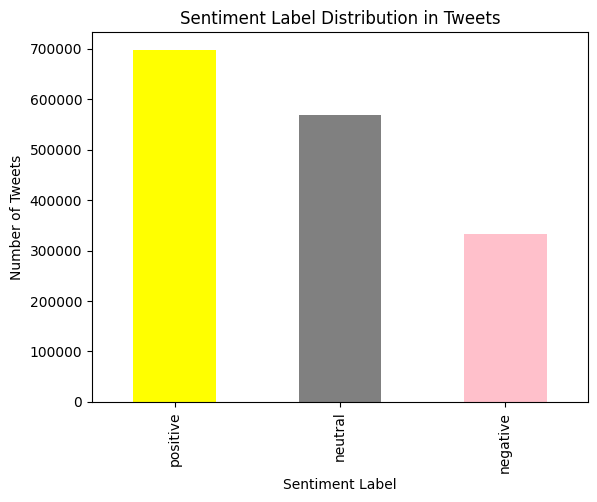

In [2]:
column_names = ['id', 'timestamp', 'query', 'user', 'tweet']

df = pd.read_csv("training.1600000.processed.noemoticon.csv", names=column_names, encoding='latin1')

df = df.dropna(subset=['tweet'])

def classify_sentiment(tweet):
    analysis = TextBlob(tweet)
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity < 0:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['tweet'].apply(classify_sentiment)

print("Sample data:")
display(df[['tweet', 'sentiment']].head(10))  

sentiment_counts = df['sentiment'].value_counts()
print("\nSentiment label distribution:")
print(sentiment_counts)

sentiment_counts.plot(kind='bar', color=['yellow', 'grey', 'pink'])
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Tweets')
plt.title('Sentiment Label Distribution in Tweets')
plt.show()


### Part 2

Sample data:


,tweet,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",positive
0,is upset that he can't update his Facebook by ...,neutral
0,@Kenichan I dived many times for the ball. Man...,positive
0,my whole body feels itchy and like its on fire,positive
0,"@nationwideclass no, it's not behaving at all....",negative
0,@Kwesidei not the whole crew,positive
0,Need a hug,neutral
0,@LOLTrish hey long time no see! Yes.. Rains a...,positive
0,@Tatiana_K nope they didn't have it,neutral
0,@twittera que me muera ?,neutral


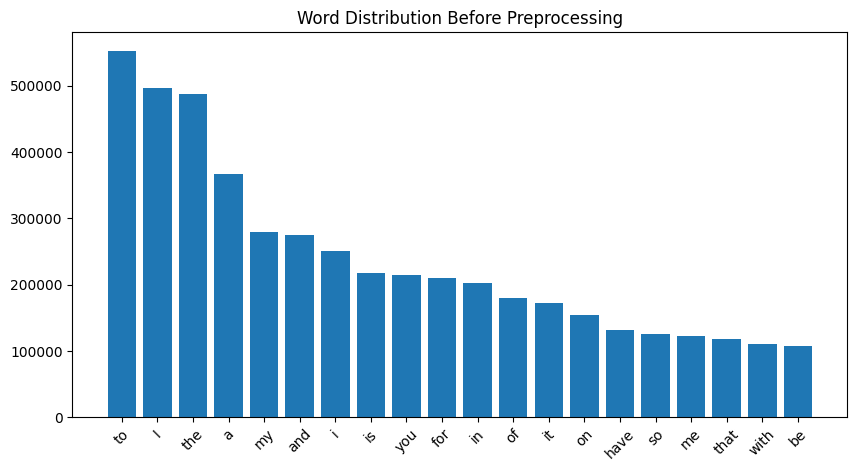

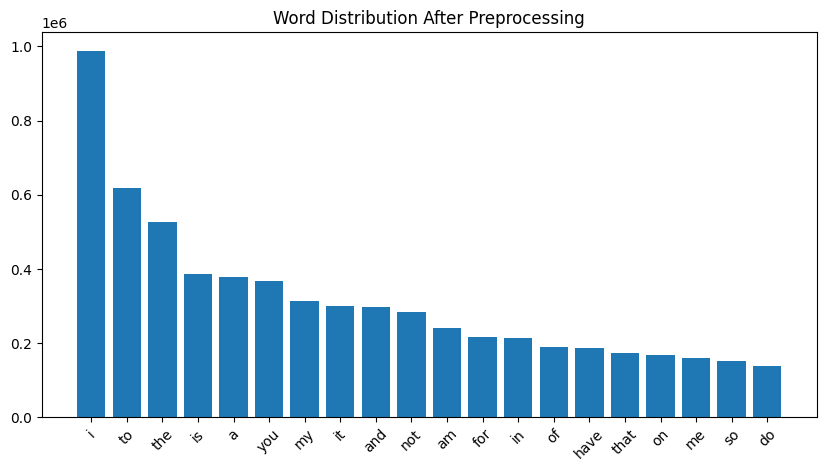

Processed Sample data:


,tweet,processed_tweet,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...","[switchfoot, awww, that, is, a, bummer, you, s...",positive
0,is upset that he can't update his Facebook by ...,"[is, upset, that, he, cannot, update, his, fac...",neutral
0,@Kenichan I dived many times for the ball. Man...,"[kenichan, i, dived, many, times, for, the, ba...",positive
0,my whole body feels itchy and like its on fire,"[my, whole, body, feels, itchy, and, like, its...",positive
0,"@nationwideclass no, it's not behaving at all....","[nationwideclass, no, it, is, not, behaving, a...",negative
0,@Kwesidei not the whole crew,"[kwesidei, not, the, whole, crew]",positive
0,Need a hug,"[need, a, hug]",neutral
0,@LOLTrish hey long time no see! Yes.. Rains a...,"[loltrish, hey, long, time, no, see, yes, rain...",positive
0,@Tatiana_K nope they didn't have it,"[tatianak, nope, they, did, not, have, it]",neutral
0,@twittera que me muera ?,"[twittera, que, me, muera]",neutral


In [5]:
import contractions

def expand(text):
    return contractions.fix(text)

def preprocess_text(text):

    text = expand(text)
    if isinstance(text, str):  
        text = text.lower()

        # Expand contractions
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+https\S+', '', text)

        # Remove mentions
        text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Normalize unicode characters
        text = unidecode(text)

        # Remove punctuation
        text = re.sub(r'[^\w\s]', '', text)

        # Tokenize by splitting
        tokens = text.split()

        return tokens
    
    return []

def get_word_counts(texts):
    all_words = [word for text in texts for word in text]
    return Counter(all_words)

def plot_word_distribution(counter, title):
    words, counts = zip(*counter.most_common(20))
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

print("Sample data:")
display(df[['tweet', 'sentiment']].head(11))

df['processed_tweet'] = df['tweet'].apply(preprocess_text)

initial_counts = get_word_counts(df['tweet'].apply(lambda x: x.split()))
plot_word_distribution(initial_counts, 'Word Distribution Before Preprocessing')

processed_counts = get_word_counts(df['processed_tweet'])
plot_word_distribution(processed_counts, 'Word Distribution After Preprocessing')

print("Processed Sample data:")
display(df[['tweet', 'processed_tweet', 'sentiment']].head(11))

### Part 3

In [6]:
def create_bow_matrix(df):
    df['tweet'] = df['tweet'].apply(lambda x: str(x) if not isinstance(x, str) else x)
    
    count_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=300)
    X_bow = count_vectorizer.fit_transform(df['tweet']).toarray()
    bow_features = count_vectorizer.get_feature_names_out()
    
    bow_df = pd.DataFrame(X_bow, columns=bow_features)
    
    bow_sums = bow_df.sum(axis=0).sort_values(ascending=False).head(10)
    print("Top 10 words in BoW matrix (by frequency):")
    print(bow_sums)
    return bow_df

bow_df = create_bow_matrix(df)
print("Bag of Words Matrix:")
display(bow_df.head(10))


Top 10 words in BoW matrix (by frequency):
to     565880
the    523872
my     316829
it     304769
and    303603
you    302036
is     238328
in     216560
for    216348
of     183804
dtype: int64
Bag of Words Matrix:


,about,after,again,all,all the,already,always,am,amazing,amp,...,ya,yay,yeah,year,yes,yet,you,you are,you re,your
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,2,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
def create_tfidf_matrix(df):
    tfidf_vectorizer = TfidfVectorizer(max_features=300)
    X_tfidf = tfidf_vectorizer.fit_transform(df['tweet']).toarray()
    tfidf_features = tfidf_vectorizer.get_feature_names_out()
    
    tfidf_sums = X_tfidf.sum(axis=0)
    
    tfidf_df = pd.DataFrame({'word': tfidf_features, 'tfidf_sum': tfidf_sums})
    
    tfidf_sums_sorted = tfidf_df.sort_values('tfidf_sum', ascending=False).head(10)
    print("Top 10 words in TF-IDF matrix (by importance):")
    print(tfidf_sums_sorted)
    
    return tfidf_df

tfidf_df = create_tfidf_matrix(df)
print("TF-IDF Sum for Each Word:")
display(tfidf_df.head(10))

Top 10 words in TF-IDF matrix (by importance):
    word      tfidf_sum
242   to  100259.492259
228  the   99370.281852
156   my   76216.281800
298  you   70061.443850
118   it   67198.124060
12   and   66356.011534
117   is   62025.965352
115   in   54282.483097
69   for   54265.446190
167   of   46860.647516
TF-IDF Sum for Each Word:


,word,tfidf_sum
0,about,17363.250438
1,actually,4290.159261
2,after,7364.588604
3,again,12392.144679
4,all,25092.625994
5,already,6578.783038
6,also,4459.159623
7,always,6243.917960
8,am,17863.086427
9,amazing,5008.484353


In [8]:
def create_word2vec(df):
    sentences = [text.split() if isinstance(text, str) else text for text in df['tweet']]
    
    word2vec_model = Word2Vec(sentences, vector_size=10, window=3, min_count=1)
    
    X_word2vec = np.array([np.mean([word2vec_model.wv[word] for word in sentence if word in word2vec_model.wv] 
                                   or [np.zeros(10)], axis=0) for sentence in sentences])
    
    return X_word2vec

word2vec = create_word2vec(df)


print("Word2Vec Embeddings:")
pd.set_option('display.max_rows', None)  
display(pd.DataFrame(word2vec).head(10))

Word2Vec Embeddings:


,0,1,2,3,4,5,6,7,8,9
0,1.433803,1.007204,1.283554,-0.018065,2.546754,2.020482,-0.234493,2.103654,-2.591723,0.783416
1,1.290241,2.252166,1.832852,0.609772,3.381649,3.758538,-0.769388,4.134835,-1.809765,1.440670
2,0.123699,2.824158,2.453433,0.579151,3.965240,2.665792,-0.890307,1.769620,-2.954967,1.012179
3,0.373262,2.180954,1.052431,1.112815,5.327541,3.158748,-0.136606,5.296538,-1.196019,2.653559
4,1.561349,1.868477,1.823614,0.879260,1.919499,4.573589,-0.068164,2.156227,-2.251824,2.366175
5,0.377534,2.855731,1.633557,1.177560,3.794711,1.768292,-1.427218,3.299435,-2.815078,1.820268
6,0.442699,2.165852,3.601210,0.451588,4.389661,3.930749,-1.882926,3.660821,-2.523350,1.301060
7,1.159353,0.543262,1.317300,0.613885,1.628246,2.890860,-0.578113,1.933597,-3.070669,2.030402
8,3.247821,2.727573,1.692215,-0.118374,1.535753,5.815990,-1.597516,2.986218,-1.504387,1.700610
9,0.881127,0.672366,1.053998,-0.668447,-0.119194,1.587238,0.476615,2.000280,-1.858743,-1.377663


In [9]:

def create_glove(df):
    sentences = [text.split() if isinstance(text, str) else text for text in df['tweet']]
    
    model = gensim.models.Word2Vec(sentences, vector_size=10, window=3, min_count=1)
    
    word2vec_model = model.wv

    X_glove = np.array([np.mean([word2vec_model[word] for word in sentence if word in word2vec_model] 
                                or [np.zeros(10)], axis=0) for sentence in sentences])
    
    return X_glove

glove = create_glove(df)

print("GloVe Embeddings:")
pd.set_option('display.max_rows', None)  
display(pd.DataFrame(glove).head(10))

GloVe Embeddings:


,0,1,2,3,4,5,6,7,8,9
0,1.514700,0.142704,0.042356,0.479677,2.231239,2.326949,0.195088,2.931430,-1.813681,1.123351
1,0.944632,0.384107,0.031939,1.383789,2.198255,4.181928,0.093658,5.056618,-0.869814,1.869551
2,0.559271,1.065047,1.307255,1.512572,3.190324,3.452538,-0.848793,3.758185,-1.670685,2.302762
3,-0.915562,-0.148942,-0.672647,1.449989,3.728334,3.701648,0.404005,6.616193,-0.427128,1.790694
4,1.251982,0.075651,-0.850142,1.614700,1.623032,4.816445,0.848451,3.010993,-1.546154,2.811489
5,0.371766,0.821546,0.225020,1.971749,2.850668,2.424903,-1.165272,4.953359,-1.645054,2.294551
6,-0.018671,-1.141283,2.334500,0.976986,2.666098,4.946803,-1.169452,5.641504,-1.189158,2.474084
7,0.865146,-0.892427,-0.532776,1.014654,1.449651,2.997161,-0.000469,2.570999,-2.597465,2.188867
8,3.266222,0.750612,-1.306121,1.283130,0.844722,6.003127,-0.082172,3.552127,-0.380163,2.561870
9,1.470425,0.065196,1.534943,-0.419951,-0.716774,1.935531,0.452240,1.988251,-1.572706,-0.575412


In [10]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def create_bow_matrix(df, column):
    df['processed_tweet'] = df[column].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
    
    count_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=300, stop_words='english')
    X_bow = count_vectorizer.fit_transform(df['processed_tweet'])  
    return X_bow

def create_tfidf_matrix(df, column):
    df['processed_tweet'] = df[column].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
    
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=300, stop_words='english')
    X_tfidf = tfidf_vectorizer.fit_transform(df['processed_tweet'])  
    return X_tfidf

def calculate_similarity(matrix1, matrix2):
    similarities = cosine_similarity(matrix1, matrix2)
    mean_similarity = np.mean(similarities)
    return mean_similarity

df_sample = df.head(1000)  

bow_similarity = calculate_similarity(create_bow_matrix(df_sample, 'tweet'), create_bow_matrix(df_sample, 'processed_tweet'))
print(f"Cosine Similarity between original and preprocessed BoW: {bow_similarity:.2f}")

tfidf_similarity = calculate_similarity(create_tfidf_matrix(df_sample, 'tweet'), create_tfidf_matrix(df_sample, 'processed_tweet'))
print(f"Cosine Similarity between original and preprocessed TF-IDF: {tfidf_similarity:.2f}")


Cosine Similarity between original and preprocessed BoW: 0.02
Cosine Similarity between original and preprocessed TF-IDF: 0.01


/tmp/ipykernel_6731/2172765637.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['processed_tweet'] = df[column].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
/tmp/ipykernel_6731/2172765637.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['processed_tweet'] = df[column].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
